In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo de Excel
archivo = 'Datos_CLV_2026_Tec_v2.xlsx'
datos = pd.read_excel(archivo, sheet_name='Negocios_CRM')

# Seleccionar las columnas asignadas para este análisis
columnas = [
    'nombre_negocio', 'estado', 'tipo_negocio', 'nombre_etapa', 'estatus',
    'fecha_creacion', 'fecha_cierre', 'numero_actividades', 'vendedor',
    'nombre_pipeline', 'nombre_zona'
]

datos = datos[columnas]
datos.head()

,nombre_negocio,estado,tipo_negocio,nombre_etapa,estatus,fecha_creacion,fecha_cierre,numero_actividades,vendedor,nombre_pipeline,nombre_zona
0,Innovacion En Diseño Y Manofactura / Fresas / Qro,Querétaro,Cliente existente,Cierre Ganado,Cerrado,2026-06-08T21:50:42.257Z,2026-06-08T22:53:13.159Z,0,Fernanda Pacheco,Pipeline De Ventas,Zona Noreste
1,Doctores Bahena / Colorimetro / Qro,Querétaro,Cliente existente,Cierre Perdido,Cerrado,2026-06-09T00:12:48.684Z,2026-06-24T20:39:32.277Z,0,Fernanda Pacheco,Pipeline De Ventas,Zona Noreste
2,Jesus Israel Lopez Casas/ 6000mp Tytan Max / Qro,Querétaro,Cliente existente,Cierre Ganado,Cerrado,2026-06-08T22:20:22.148Z,2026-06-24T22:13:35.26Z,2,Fernanda Pacheco,Pipeline De Ventas,Zona Noreste
3,Esthetic Dental Project / Asiga / Qro,Querétaro,Cliente existente,Cierre Ganado,Cerrado,2026-06-08T19:06:34.126Z,2026-06-09T22:22:07.18Z,0,Fernanda Pacheco,Pipeline De Ventas,Zona Noreste
4,Innovacion En Diseño Y Manufactura Dental / Di...,Querétaro,Cliente existente,Cierre Ganado,Cerrado,2026-06-08T18:23:55.735Z,2026-06-08T21:06:47.96Z,0,Fernanda Pacheco,Pipeline De Ventas,Zona Noreste


In [26]:
# Ver cuántos valores vacíos hay antes de limpiar
print(" Valores vacíos de cada columna")
print(datos.isnull().sum())

# Eliminar todas las filas que tengan algún valor vacío
datos = datos.dropna().reset_index(drop=True)

print("\n Verificación de eliminar nulos")
print(datos.isnull().sum())
print("Total de registros limpios para analizar:", len(datos))

# Asegurar que el número de actividades sea un número
datos['numero_actividades'] = pd.to_numeric(datos['numero_actividades'], errors='coerce')

 Valores vacíos de cada columna
nombre_negocio           0
estado                 149
tipo_negocio           560
nombre_etapa            22
estatus                  0
fecha_creacion           0
fecha_cierre            45
numero_actividades      17
vendedor               406
nombre_pipeline          0
nombre_zona           1142
dtype: int64

 Verificación de eliminar nulos
nombre_negocio        0
estado                0
tipo_negocio          0
nombre_etapa          0
estatus               0
fecha_creacion        0
fecha_cierre          0
numero_actividades    0
vendedor              0
nombre_pipeline       0
nombre_zona           0
dtype: int64
Total de registros limpios para analizar: 3576


Frecuencias de: estado
estado
Estado De México    707
Ciudad De México    599
Puebla              513
Tamaulipas          230
Jalisco             185
Nuevo León          182
Coahuila            174
Querétaro           147
Guanajuato           94
Yucatán              81
Name: count, dtype: int64




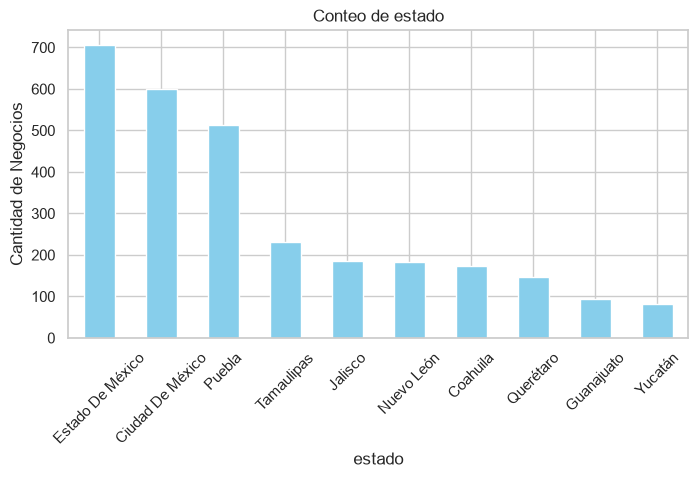

Frecuencias de: tipo_negocio
tipo_negocio
Cliente existente    2968
Cliente nuevo         608
Name: count, dtype: int64




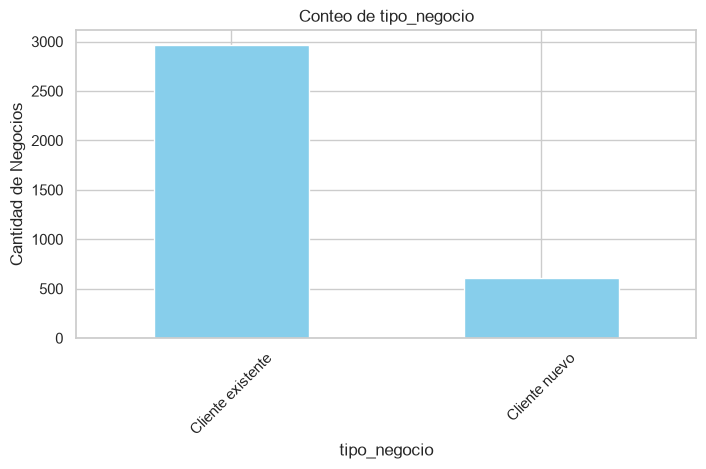

Frecuencias de: nombre_etapa
nombre_etapa
Cierre Ganado                     2644
Cierre Perdido                     446
Ganado                             305
Perdido                             83
Negociación                         38
Cotización                          27
Necesidad Descubierta                9
Calificado Para Comprar              7
Recepción De Pago / Financiera       6
Envío De Cotización                  5
Name: count, dtype: int64




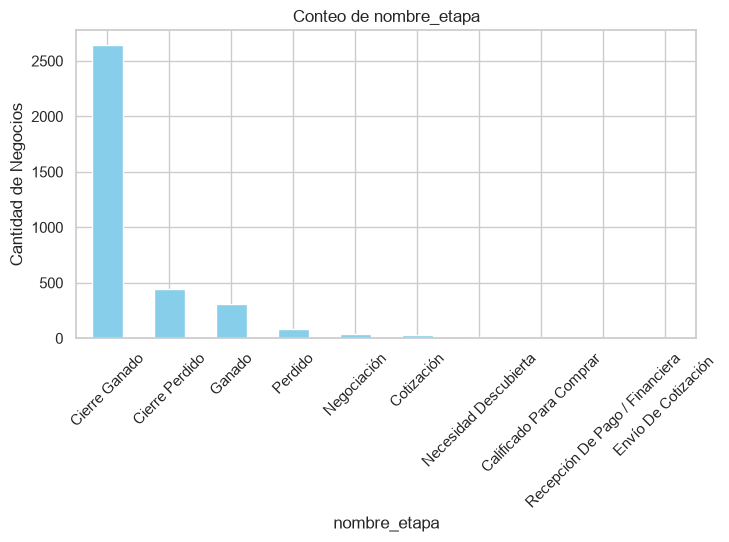

Frecuencias de: estatus
estatus
Cerrado    3479
Abierto      97
Name: count, dtype: int64




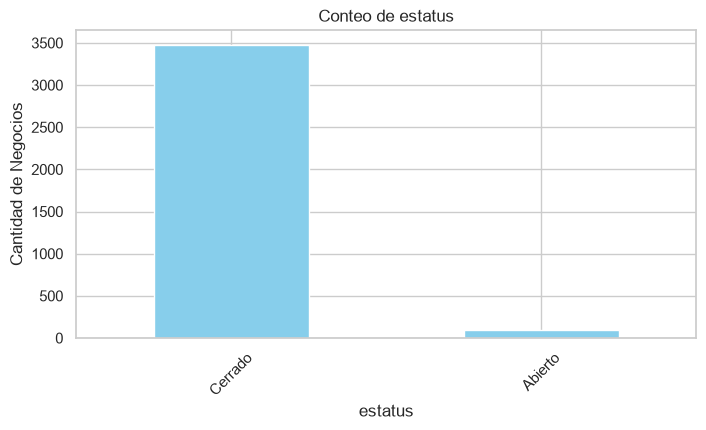

Frecuencias de: vendedor
vendedor
Diego Rodríguez        1030
Gerardo García          988
Juan Cadena             368
René Sánchez            333
Ángel Salas             231
Erick Juárez            156
Pietro Pérez            121
Fernanda Pacheco         96
Marcos Islas             46
Jerónimo Villarreal      32
Name: count, dtype: int64




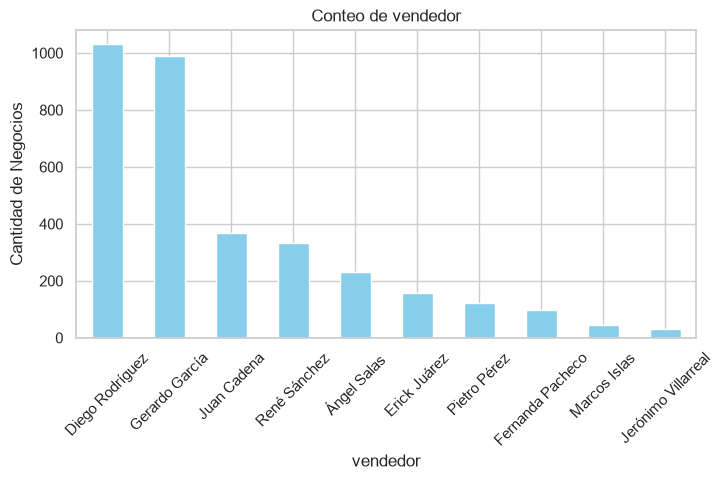

Frecuencias de: nombre_pipeline
nombre_pipeline
Pipeline De Ventas    3035
Ventas - Main          465
Mapeo En Ruta           75
Educación Contínua       1
Name: count, dtype: int64




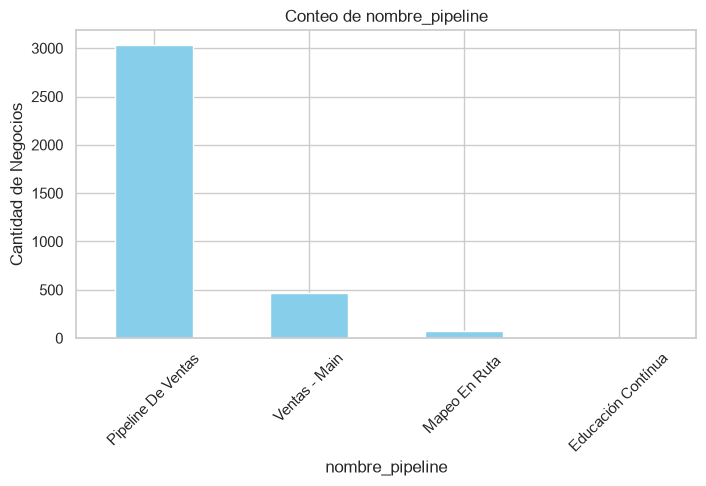

Frecuencias de: nombre_zona
nombre_zona
Zona Metropolitana               1401
Zona Sur Este Golfo de México    1169
Zona Bajío                        504
Zona Occidente Pacífico           375
Zona Noreste                      127
Name: count, dtype: int64




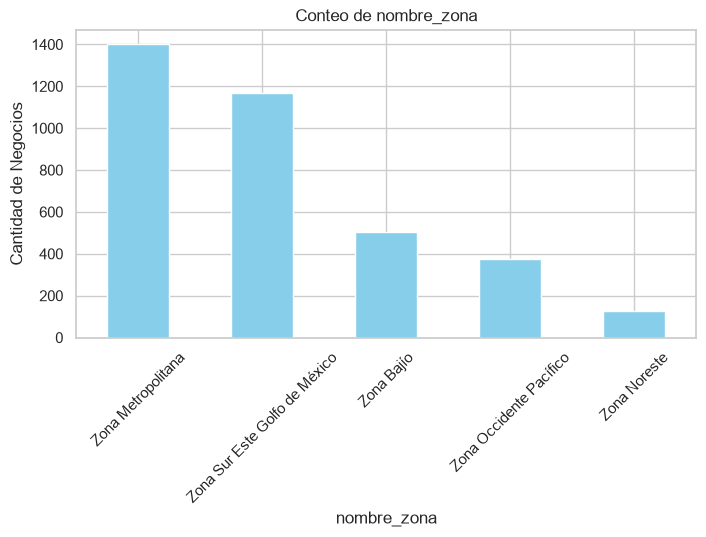

In [27]:
# Lista de columnas categóricas a analizar
columnas_texto = ['estado', 'tipo_negocio', 'nombre_etapa', 'estatus', 'vendedor', 'nombre_pipeline', 'nombre_zona']

for col in columnas_texto:
    # Contar la frecuencia de los 10 valores más comunes
    conteo = datos[col].value_counts().head(10)
    
    # Mostrar la tabla de resultados
    print("Frecuencias de:", col)
    print(conteo)
    print("\n")
    
    # Crear gráfica de barras
    plt.figure(figsize=(8, 4))
    conteo.plot(kind='bar', color='skyblue')
    plt.title('Conteo de ' + col)
    plt.xlabel(col)
    plt.ylabel('Cantidad de Negocios')
    plt.xticks(rotation=45)
    plt.show()

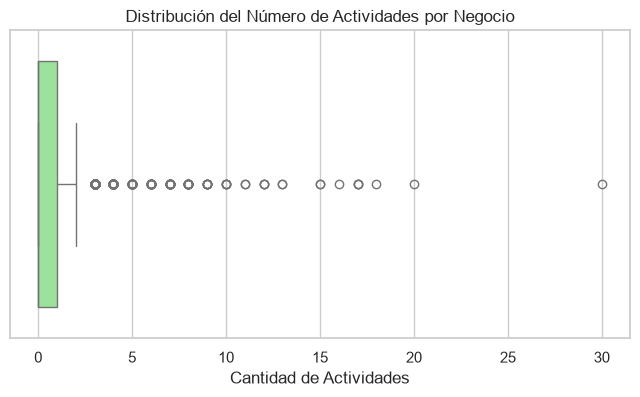

In [29]:
# Gráfica para ver la distribución del número de actividades por negocio
plt.figure(figsize=(8, 4))
sns.boxplot(x=datos['numero_actividades'], color='lightgreen')
plt.title('Distribución del Número de Actividades por Negocio')
plt.xlabel('Cantidad de Actividades')
plt.show()